# US-08b – WAE-GAN Fault Diagnoser (Two-Stage Pipeline)

**Objetivo:** Construir um sistema de diagnóstico de falhas em duas etapas sobre o WAE-GAN já treinado.

**Padronização de seeds/runs:** este notebook é executado de forma pareada com os treinos de GAT/Transformer/WAE-GAN via `RUN_ID` (1..20), usando a seed correspondente na lista fixa `42..61`.

## Conceito

O WAE-GAN treinado **somente** com dados normais comprime o comportamento saudável do sistema em uma distribuição Gaussiana no espaço latente. Quando janelas de falha passam pelo encoder, elas chegam a regiões *fora* do cluster normal — e falhas de naturezas diferentes tendem a cair em regiões **distintas**.

### Pipeline de Dois Estágios

| Estágio | Modelo | Entrada | Saída |
|---------|--------|---------|-------|
| 1 – Detecção | WAE-GAN (frozen) | Janela bruta (N, T, F) | `anomaly_score`, `is_anomaly` |
| 2 – Diagnóstico | Random Forest / SVM / XGBoost | Vetor latente GAP (N, emb_dim) | `fault_label` |

**Global Average Pooling (GAP):** A saída do encoder `(B, T, embedding_dim)` é reduzida a `(B, embedding_dim)` calculando a média sobre o eixo do tempo.

**Vantagens:**
- O WAE-GAN nunca precisa ser re-treinado para novos tipos de falha.
- O espaço latente funciona como filtro de ruído, entregando ao classificador apenas a "essência" do comportamento.
- O classificador é treinado e re-treinado em milissegundos.

**Entradas:** `data/processed/X_*.npy`, `y_*.npy` e `models/wae_gan_runs_20/wae_gan_run_XX.pt`

## 1. Setup e Seeds

In [ ]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# -- Environment detection (local vs Google Colab) --------------------------------
IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

if IN_COLAB:
    COLAB_REPO = Path("/content/anomaly_detection_models_comparison")
    if not COLAB_REPO.exists():
        os.system(
            "git clone https://github.com/camara0729/anomaly_detection_models_comparison.git "
            "/content/anomaly_detection_models_comparison"
        )
    PROJECT_ROOT = COLAB_REPO
else:
    PROJECT_ROOT = (
        Path(__file__).resolve().parents[1]
        if "__file__" in dir()
        else Path(".").resolve().parent
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.wae_gan import WAEGAN
from src.models.wae_gan_diagnoser import WAEGAN_FaultDiagnoser, FaultDiagnoserConfig
from src.preprocessing import make_waegan_anomaly_splits, to_sequence_last
from src.evaluation import compute_anomaly_metrics

# -- Run/seed pairing (same protocol as model training notebooks) ------------------
NUM_RUNS = 20
RUN_SEEDS = list(range(42, 42 + NUM_RUNS))  # 42..61
RUN_ID = 1  # altere para 1..20 para avaliar o run pareado
assert 1 <= RUN_ID <= NUM_RUNS, f"RUN_ID deve estar em [1, {NUM_RUNS}]"

# -- Seeds -------------------------------------------------------------------------
RANDOM_SEED = RUN_SEEDS[RUN_ID - 1]
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# -- Device ------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Run pairing: RUN_ID={RUN_ID:02d}, seed={RANDOM_SEED}")

c:\implementations\anomaly_detection_comparison\anomaly_detection_models_comparison\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
  GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU
Project root: C:\implementations\anomaly_detection_comparison\anomaly_detection_models_comparison


## 2. Carregar Dados

In [2]:
DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "docs" / "figures"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

X_train = np.load(DATA_DIR / "X_train.npy")   # (N_tr, 9, 4096) channels-first
y_train = np.load(DATA_DIR / "y_train.npy")   # multiclass: 0,1,2,3
X_val   = np.load(DATA_DIR / "X_val.npy")
y_val   = np.load(DATA_DIR / "y_val.npy")
X_test  = np.load(DATA_DIR / "X_test.npy")
y_test  = np.load(DATA_DIR / "y_test.npy")

print("X_train:", X_train.shape, "  classes:", np.unique(y_train))
print("X_val:  ", X_val.shape,   "  classes:", np.unique(y_val))
print("X_test: ", X_test.shape,  "  classes:", np.unique(y_test))

X_train: (9720, 9, 4096)   classes: [0 1 2 3]
X_val:   (1944, 9, 4096)   classes: [0 1 2 3]
X_test:  (2916, 9, 4096)   classes: [0 1 2 3]


## 3. Preparar Splits

Usamos `make_waegan_anomaly_splits` para obter os dados no formato sequencial `(N, T, F)` exigido pelo WAE-GAN, preservando os rótulos multiclasse originais para treinar o classificador.

In [3]:
NORMAL_LABEL = 0
CLASS_NAMES  = ["Normal (P1)", "Fault A (P2)", "Fault B (P3)", "Fault C (P4)"]

splits = make_waegan_anomaly_splits(
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    normal_label=NORMAL_LABEL,
)

# Sequence-last arrays returned by make_waegan_anomaly_splits
X_train_normal = splits["X_train_normal"]     # (N_normal, T, F)
X_val_normal   = splits["X_val_normal"]
X_test_seq     = splits["X_test"]              # all classes
y_test_binary  = splits["y_test_binary"]       # 0=normal, 1=anomaly
y_test_multi   = splits["y_test_multiclass"]   # original 0/1/2/3 labels

# Convert full train split to sequence-last keeping all classes
X_train_seq = to_sequence_last(X_train)        # (N_tr, T, F) all classes
X_val_seq   = to_sequence_last(X_val)

# Build per-class dicts for the diagnoser's fit() method
def make_data_by_label(X_seq: np.ndarray, y: np.ndarray) -> dict:
    return {lbl: X_seq[y == lbl] for lbl in np.unique(y)}

train_by_label = make_data_by_label(X_train_seq, y_train)
val_by_label   = make_data_by_label(X_val_seq, y_val)
test_by_label  = make_data_by_label(X_test_seq, y_test_multi)

print("Train splits per class (sequence-last):")
for lbl, arr in train_by_label.items():
    print(f"  [{lbl}] {CLASS_NAMES[lbl]}: {arr.shape}")

print("\nTest splits per class:")
for lbl, arr in test_by_label.items():
    print(f"  [{lbl}] {CLASS_NAMES[lbl]}: {arr.shape}")

Train splits per class (sequence-last):
  [0] Normal (P1): (2430, 4096, 9)
  [1] Fault A (P2): (2430, 4096, 9)
  [2] Fault B (P3): (2430, 4096, 9)
  [3] Fault C (P4): (2430, 4096, 9)

Test splits per class:
  [0] Normal (P1): (729, 4096, 9)
  [1] Fault A (P2): (729, 4096, 9)
  [2] Fault B (P3): (729, 4096, 9)
  [3] Fault C (P4): (729, 4096, 9)


## 4. Carregar WAE-GAN Treinado (Pesos Congelados)

In [ ]:
WAEGAN_RUNS_ROOT = MODELS_DIR / "wae_gan_runs_20"
target_name = f"wae_gan_run_{RUN_ID:02d}.pt"

direct_checkpoint = WAEGAN_RUNS_ROOT / target_name
if direct_checkpoint.exists():
    WAEGAN_CHECKPOINT = direct_checkpoint
else:
    candidates = sorted(
        WAEGAN_RUNS_ROOT.glob(f"runset*/{target_name}"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not candidates:
        raise FileNotFoundError(
            f"Checkpoint do run nao encontrado para RUN_ID={RUN_ID:02d} em {WAEGAN_RUNS_ROOT}. "
            f"Execute primeiro o notebook 05 para gerar os 20 modelos."
        )
    WAEGAN_CHECKPOINT = candidates[0]

waegan = WAEGAN.load(WAEGAN_CHECKPOINT, map_location=str(DEVICE))
waegan.model.eval()

n_params = sum(p.numel() for p in waegan.model.parameters())
print(f"WAE-GAN loaded from: {WAEGAN_CHECKPOINT.relative_to(PROJECT_ROOT)}")
print(f"  runset_dir     : {WAEGAN_CHECKPOINT.parent.name}")
print(f"  run_id         : {RUN_ID:02d}")
print(f"  seed           : {RANDOM_SEED}")
print(f"  embedding_dim  : {waegan.config.embedding_dim}")
print(f"  n_features     : {waegan.config.n_features}")
print(f"  total params   : {n_params:,}")
print(f"  best_epoch     : {waegan.best_epoch_}")
print(f"  best_monitor   : {waegan.best_monitor_value_:.6f}")

c:\implementations\anomaly_detection_comparison\anomaly_detection_models_comparison\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


WAE-GAN loaded from: models\wae_gan_best.pt
  embedding_dim : 64
  n_features    : 9
  total params  : 102,635
  best_epoch    : 2
  best_monitor  : 3.063688


## 5. Configuração e Inicialização do Diagnoser

In [ ]:
CLASSIFIER_TYPE = "random_forest"   # "random_forest" | "svm" | "xgboost"
N_ESTIMATORS    = 300
THRESHOLD_MULT  = 1.5
DIAGNOSER_PATH  = MODELS_DIR / f"wae_gan_fault_diagnoser_run_{RUN_ID:02d}.pkl"

config = FaultDiagnoserConfig(
    classifier=CLASSIFIER_TYPE,
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_SEED,
    class_names=CLASS_NAMES,
)

diagnoser = WAEGAN_FaultDiagnoser(waegan=waegan, config=config)
print("Diagnoser initialized.")
print(f"  run_id      : {RUN_ID:02d}")
print(f"  seed        : {RANDOM_SEED}")
print(f"  classifier  : {config.classifier}")
print(f"  n_estimators: {config.n_estimators}")

Diagnoser initialized.
  classifier : random_forest
  n_estimators: 300


## 6. Extração de Features Latentes (Passo 2 do Conceito)

Usamos o encoder congelado para projetar todas as janelas (treino + teste) no espaço latente, aplicando **Global Average Pooling** sobre o eixo do tempo: `(B, T, emb_dim) → (B, emb_dim)`.

In [6]:
print("Extracting latent features for all splits...")
t0 = time.time()

# Build latent representations for each class in the TEST set
latent_by_class = {}
for lbl, arr in test_by_label.items():
    latent_by_class[lbl] = diagnoser.extract_latent_features(arr)
    print(f"  [{lbl}] {CLASS_NAMES[lbl]}: {latent_by_class[lbl].shape}")

print(f"\nExtraction time: {time.time() - t0:.2f}s")

Extracting latent features for all splits...
  [0] Normal (P1): (729, 64)
  [1] Fault A (P2): (729, 64)
  [2] Fault B (P3): (729, 64)
  [3] Fault C (P4): (729, 64)

Extraction time: 3.04s


### 6.1 Visualização do Espaço Latente (PCA + t-SNE)

Verificamos se as falhas formam clusters visualmente separáveis no espaço latente comprimido pelo GAP.

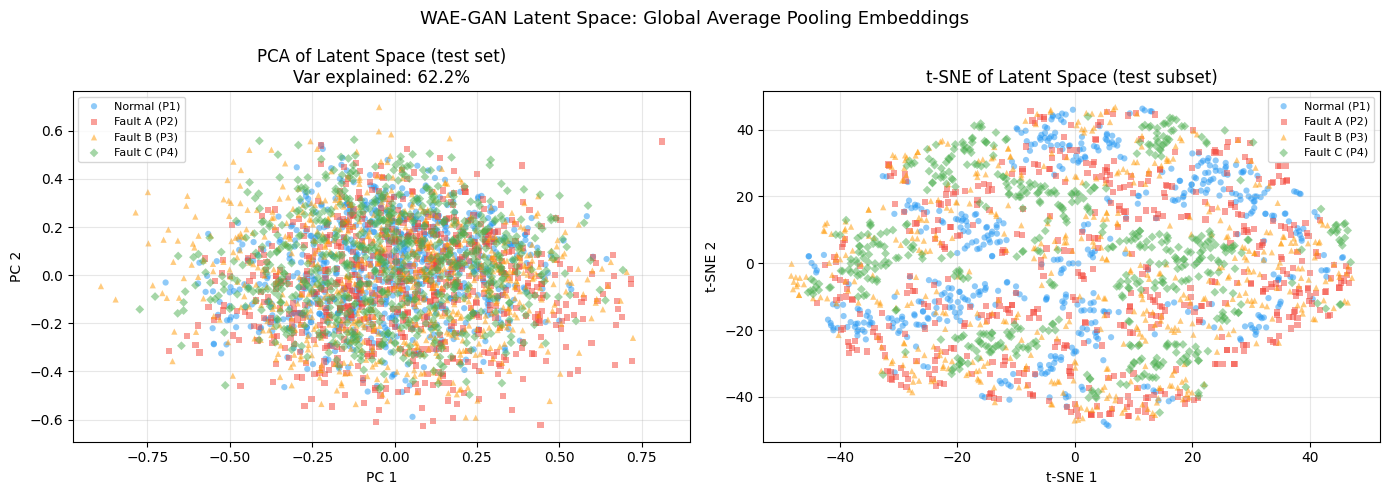

Saved: docs\figures\08_latent_space_visualization.png


In [7]:
# Concatenate all test latent vectors
X_latent_test = np.vstack([latent_by_class[lbl] for lbl in sorted(latent_by_class)])
y_latent_test = np.concatenate([
    np.full(len(latent_by_class[lbl]), lbl)
    for lbl in sorted(latent_by_class)
])

COLORS = ["#2196F3", "#F44336", "#FF9800", "#4CAF50"]
MARKERS = ["o", "s", "^", "D"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── PCA ───────────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=RANDOM_SEED)
Z_pca = pca.fit_transform(X_latent_test)

for lbl in sorted(latent_by_class):
    mask = y_latent_test == lbl
    axes[0].scatter(
        Z_pca[mask, 0], Z_pca[mask, 1],
        c=COLORS[lbl], marker=MARKERS[lbl],
        label=CLASS_NAMES[lbl], alpha=0.5, s=20, edgecolors="none",
    )
axes[0].set_title(
    f"PCA of Latent Space (test set)\n"
    f"Var explained: {pca.explained_variance_ratio_.sum():.1%}"
)
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# ── t-SNE ──────────────────────────────────────────────────────────────────
# Subsample for speed if needed
MAX_TSNE = 2000
if len(X_latent_test) > MAX_TSNE:
    rng = np.random.default_rng(RANDOM_SEED)
    idx = rng.choice(len(X_latent_test), MAX_TSNE, replace=False)
    X_sub, y_sub = X_latent_test[idx], y_latent_test[idx]
else:
    X_sub, y_sub = X_latent_test, y_latent_test

tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_SEED, n_jobs=-1)
Z_tsne = tsne.fit_transform(X_sub)

for lbl in sorted(latent_by_class):
    mask = y_sub == lbl
    axes[1].scatter(
        Z_tsne[mask, 0], Z_tsne[mask, 1],
        c=COLORS[lbl], marker=MARKERS[lbl],
        label=CLASS_NAMES[lbl], alpha=0.5, s=20, edgecolors="none",
    )
axes[1].set_title("t-SNE of Latent Space (test subset)")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle("WAE-GAN Latent Space: Global Average Pooling Embeddings", fontsize=13)
plt.tight_layout()
save_path = FIGURES_DIR / "08_latent_space_visualization.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", save_path.relative_to(PROJECT_ROOT))

## 7. Treinamento do Classificador (Passo 3 do Conceito)

Treinamos o classificador supervisionado usando os vetores latentes do conjunto de **treino** (todas as classes).

In [8]:
t_fit = time.time()

diagnoser.fit(
    data_by_label=train_by_label,
    normal_label=NORMAL_LABEL,
    threshold_multiplier=THRESHOLD_MULT,
    verbose=True,
)

fit_time = time.time() - t_fit
print(f"\nFit time: {fit_time:.2f}s")
print(f"Anomaly threshold: {diagnoser.config.anomaly_threshold:.6f}")

── Stage 2: extracting latent features ─────────────────────
  [0] Normal (P1): 2430 samples
  [1] Fault A (P2): 2430 samples
  [2] Fault B (P3): 2430 samples
  [3] Fault C (P4): 2430 samples

Computing anomaly threshold from normal windows...
  threshold = 0.154959

Training random_forest on 9720 samples × 64 latent dims...
  In-sample accuracy: 1.0000

Fit time: 14.41s
Anomaly threshold: 0.154959


## 8. Avaliação – Pipeline Completo no Conjunto de Teste (Passo 4 do Conceito)

### 8.1 Detecção de Anomalias (Estágio 1)

In [9]:
t_pred = time.time()
results = diagnoser.predict(X_test_seq)
pred_time = time.time() - t_pred

anomaly_scores = results["anomaly_score"]
is_anomaly     = results["is_anomaly"]
fault_label    = results["fault_label"]

print(f"Prediction time: {pred_time:.2f}s  ({pred_time / len(X_test_seq) * 1000:.3f} ms/sample)")
print(f"\nAnomaly detection (Stage 1):")
anomaly_metrics = compute_anomaly_metrics(
    y_test_binary, anomaly_scores,
    threshold=diagnoser.config.anomaly_threshold,
)
display(pd.Series(anomaly_metrics).to_frame("value"))

Prediction time: 6.21s  (2.131 ms/sample)

Anomaly detection (Stage 1):


,value
auc_roc,1.000000
average_precision,1.000000
threshold,0.154959
accuracy,0.996228
precision,0.994995
recall,1.000000
f1,0.997491
tn,718.000000
fp,11.000000
fn,0.000000


### 8.2 Diagnóstico de Falhas (Estágio 2)

Avaliamos a classificação multiclasse somente sobre as janelas **detectadas como anômalas** pelo Estágio 1.

In [10]:
# Mask to anomalous windows actually flagged by Stage 1
flagged_mask = is_anomaly
y_true_flagged  = y_test_multi[flagged_mask]    # ground-truth multiclass labels
y_pred_flagged  = fault_label[flagged_mask]      # classifier predictions

print("Fault classification report (on anomaly-flagged windows):")
print(classification_report(
    y_true_flagged, y_pred_flagged,
    target_names=[CLASS_NAMES[i] for i in sorted(np.unique(y_true_flagged))],
))

Fault classification report (on anomaly-flagged windows):
              precision    recall  f1-score   support

 Normal (P1)       0.18      0.82      0.30        11
Fault A (P2)       0.80      0.77      0.78       729
Fault B (P3)       0.79      0.77      0.78       729
Fault C (P4)       0.97      0.97      0.97       729

    accuracy                           0.84      2198
   macro avg       0.68      0.83      0.71      2198
weighted avg       0.85      0.84      0.84      2198



### 8.3 Avaliação Multiclasse Completa (Incluindo Normal)

Avaliamos o pipeline completo de ponta a ponta: janelas normais devem ser previstas como `Normal` (label −1 convertido para 0) e falhas devem receber o rótulo correto.

In [11]:
# Map pipeline output to multiclass labels:
# - fault_label == -1 (Stage 1 said "Normal") → predicted class = 0
# - fault_label  > -1 (Stage 2 output)        → use as-is
y_pred_full = fault_label.copy()
y_pred_full[fault_label == -1] = NORMAL_LABEL   # Normal windows

print("End-to-end multiclass classification report (all test windows):")
print(classification_report(
    y_test_multi, y_pred_full,
    target_names=CLASS_NAMES,
))

End-to-end multiclass classification report (all test windows):
              precision    recall  f1-score   support

 Normal (P1)       0.95      1.00      0.97       729
Fault A (P2)       0.80      0.77      0.78       729
Fault B (P3)       0.79      0.77      0.78       729
Fault C (P4)       0.97      0.97      0.97       729

    accuracy                           0.88      2916
   macro avg       0.87      0.88      0.88      2916
weighted avg       0.87      0.88      0.88      2916



### 8.4 Matriz de Confusão

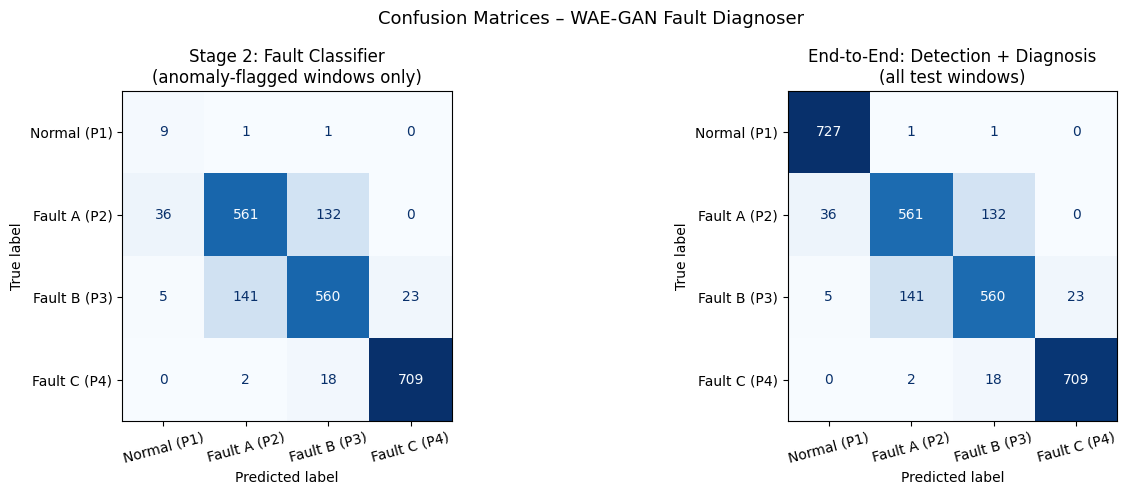

Saved: docs\figures\08_fault_diagnoser_confusion.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Stage 2 only (anomaly windows) ───────────────────────────────────────
cm_stage2 = confusion_matrix(y_true_flagged, y_pred_flagged)
ConfusionMatrixDisplay(
    cm_stage2,
    display_labels=[CLASS_NAMES[i] for i in sorted(np.unique(y_true_flagged))],
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Stage 2: Fault Classifier\n(anomaly-flagged windows only)")
axes[0].tick_params(axis="x", rotation=15)

# ── End-to-end ────────────────────────────────────────────────────────────
cm_full = confusion_matrix(y_test_multi, y_pred_full)
ConfusionMatrixDisplay(cm_full, display_labels=CLASS_NAMES).plot(
    ax=axes[1], colorbar=False, cmap="Blues"
)
axes[1].set_title("End-to-End: Detection + Diagnosis\n(all test windows)")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Confusion Matrices – WAE-GAN Fault Diagnoser", fontsize=13)
plt.tight_layout()
save_path = FIGURES_DIR / "08_fault_diagnoser_confusion.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", save_path.relative_to(PROJECT_ROOT))

### 8.5 Distribuição de Scores e Importância de Features (Random Forest)

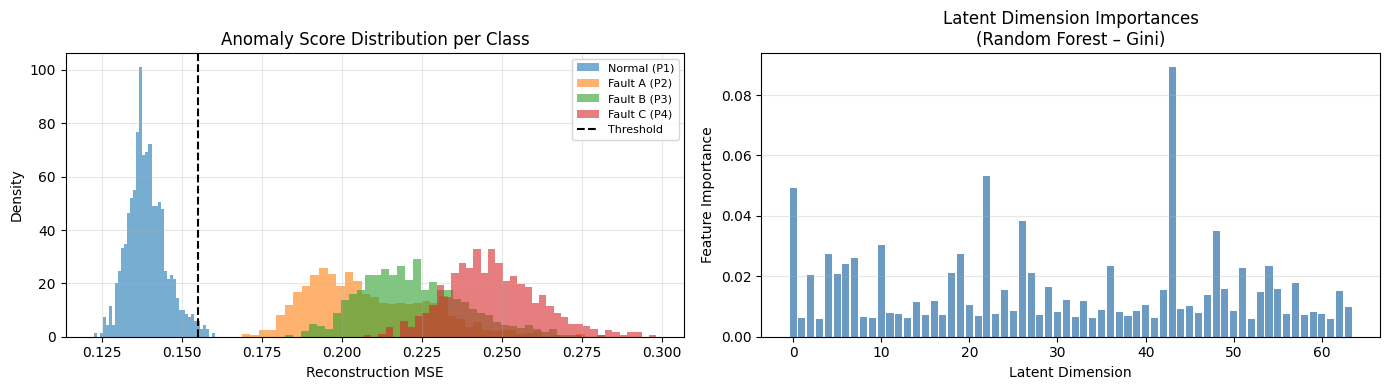

Saved: docs\figures\08_fault_diagnoser_analysis.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Score distribution per class ──────────────────────────────────────────
for lbl in sorted(test_by_label):
    mask = y_test_multi == lbl
    axes[0].hist(
        anomaly_scores[mask], bins=40, alpha=0.6,
        label=CLASS_NAMES[lbl], density=True,
    )
axes[0].axvline(
    diagnoser.config.anomaly_threshold,
    color="black", linestyle="--", linewidth=1.5, label="Threshold"
)
axes[0].set_title("Anomaly Score Distribution per Class")
axes[0].set_xlabel("Reconstruction MSE")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# ── Feature importances (Random Forest only) ──────────────────────────────
if CLASSIFIER_TYPE == "random_forest":
    importances = diagnoser.classifier_.feature_importances_
    emb_dim = waegan.config.embedding_dim
    axes[1].bar(range(emb_dim), importances, color="steelblue", alpha=0.8)
    axes[1].set_title("Latent Dimension Importances\n(Random Forest – Gini)")
    axes[1].set_xlabel("Latent Dimension")
    axes[1].set_ylabel("Feature Importance")
    axes[1].grid(True, alpha=0.3, axis="y")
else:
    axes[1].text(0.5, 0.5, f"Feature importances\nnot shown for {CLASSIFIER_TYPE}",
                 ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_title("Feature Importances")

plt.tight_layout()
save_path = FIGURES_DIR / "08_fault_diagnoser_analysis.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", save_path.relative_to(PROJECT_ROOT))

## 9. Comparação de Classificadores

Treinamos Random Forest, SVM e (opcionalmente) XGBoost para comparação rápida.

In [14]:
from sklearn.metrics import accuracy_score, f1_score

CLASSIFIERS_TO_COMPARE = ["random_forest", "svm", "xgboost"]
# Add "xgboost" above if xgboost is installed


comparison_rows = []

for clf_name in CLASSIFIERS_TO_COMPARE:
    cfg = FaultDiagnoserConfig(
        classifier=clf_name,
        n_estimators=200,
        random_state=RANDOM_SEED,
        class_names=CLASS_NAMES,
        # Reuse the already-computed threshold
        anomaly_threshold=diagnoser.config.anomaly_threshold,
    )
    d = WAEGAN_FaultDiagnoser(waegan=waegan, config=cfg)

    t0 = time.time()
    d.fit(train_by_label, normal_label=NORMAL_LABEL, verbose=False)
    fit_s = time.time() - t0

    t0 = time.time()
    res = d.predict(X_test_seq)
    pred_s = time.time() - t0

    y_pred = res["fault_label"].copy()
    y_pred[y_pred == -1] = NORMAL_LABEL

    comparison_rows.append({
        "classifier": clf_name,
        "accuracy": accuracy_score(y_test_multi, y_pred),
        "f1_macro": f1_score(y_test_multi, y_pred, average="macro"),
        "fit_time_s": round(fit_s, 2),
        "pred_time_s": round(pred_s, 2),
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("classifier")
print("Classifier Comparison (end-to-end on test set):")
display(comparison_df)

c:\implementations\anomaly_detection_comparison\anomaly_detection_models_comparison\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:38:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classifier Comparison (end-to-end on test set):


,accuracy,f1_macro,fit_time_s,pred_time_s
classifier,,,,
random_forest,0.879287,0.877997,9.59,6.41
svm,0.652949,0.632636,46.06,12.02
xgboost,0.952675,0.952439,13.16,6.27


## 10. Persistência

In [15]:
diagnoser.save(
    path=DIAGNOSER_PATH,
    # The WAE-GAN is already saved; no need to re-save it here.
    waegan_path=None,
)
print(f"Diagnoser saved to: {DIAGNOSER_PATH.relative_to(PROJECT_ROOT)}")

# ── Round-trip test ───────────────────────────────────────────────────────
diagnoser_loaded = WAEGAN_FaultDiagnoser.load(
    path=DIAGNOSER_PATH,
    waegan=waegan,
)
res_rt = diagnoser_loaded.predict(X_test_seq[:10])
print("Round-trip predict OK. fault_label sample:", res_rt["fault_label"])

Diagnoser saved to: models\wae_gan_fault_diagnoser.pkl
Round-trip predict OK. fault_label sample: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


## 11. Resumo

| Item | Valor |
|------|-------|
| Run avaliado | `RUN_ID` (1..20) |
| Seed do run | `RUN_SEEDS[RUN_ID-1]` |
| WAE-GAN checkpoint | `models/wae_gan_runs_20/wae_gan_run_XX.pt` |
| Diagnoser checkpoint | `models/wae_gan_fault_diagnoser_run_XX.pkl` |
| Embedding dim (GAP) | depende do run carregado |
| Classifier | Random Forest / SVM / XGBoost |

**Artefatos gerados:**
- `models/wae_gan_fault_diagnoser_run_XX.pkl`
- `docs/figures/08_latent_space_visualization.png`
- `docs/figures/08_fault_diagnoser_confusion.png`
- `docs/figures/08_fault_diagnoser_analysis.png`

### Fluxo em Produção

```
Janela (N, T, F)
      │
      ▼
  Encoder TCN (WAE-GAN frozen do run pareado)
      │ (B, T, emb_dim)
      ▼
  Decoder TCN → MSE → anomaly_score
      │
      ▼
  score < threshold? → "Normal" ✓ (pipeline encerra)
      │ score ≥ threshold
      ▼
  Global Average Pooling → (B, emb_dim)
      │
      ▼
  Classifier → "Fault A / B / C" ✓
```